# Experiment 6: Bagging, Boosting, and Stacked Ensemble Models

Comparative analysis of ensemble learning paradigms (Bagging, Boosting, and Stacking) on the Wisconsin Diagnostic Breast Cancer (WDBC) dataset.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

sns.set_style("whitegrid")
SEED_VAL = 42


## 1. Load Dataset and Encode Target Labels


In [2]:
cancer_dataset = load_breast_cancer()
X_features = pd.DataFrame(cancer_dataset.data, columns=cancer_dataset.feature_names)
y_target = pd.Series(cancer_dataset.target, name="diagnosis") # 0=malignant, 1=benign

print("Dataset Matrix Shape:", X_features.shape)
print("Null values present:", X_features.isnull().sum().sum())
y_target.map({0: "malignant", 1: "benign"}).value_counts()


Dataset Matrix Shape: (569, 30)
Null values present: 0


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## 2. Exploratory Data Analysis (EDA)


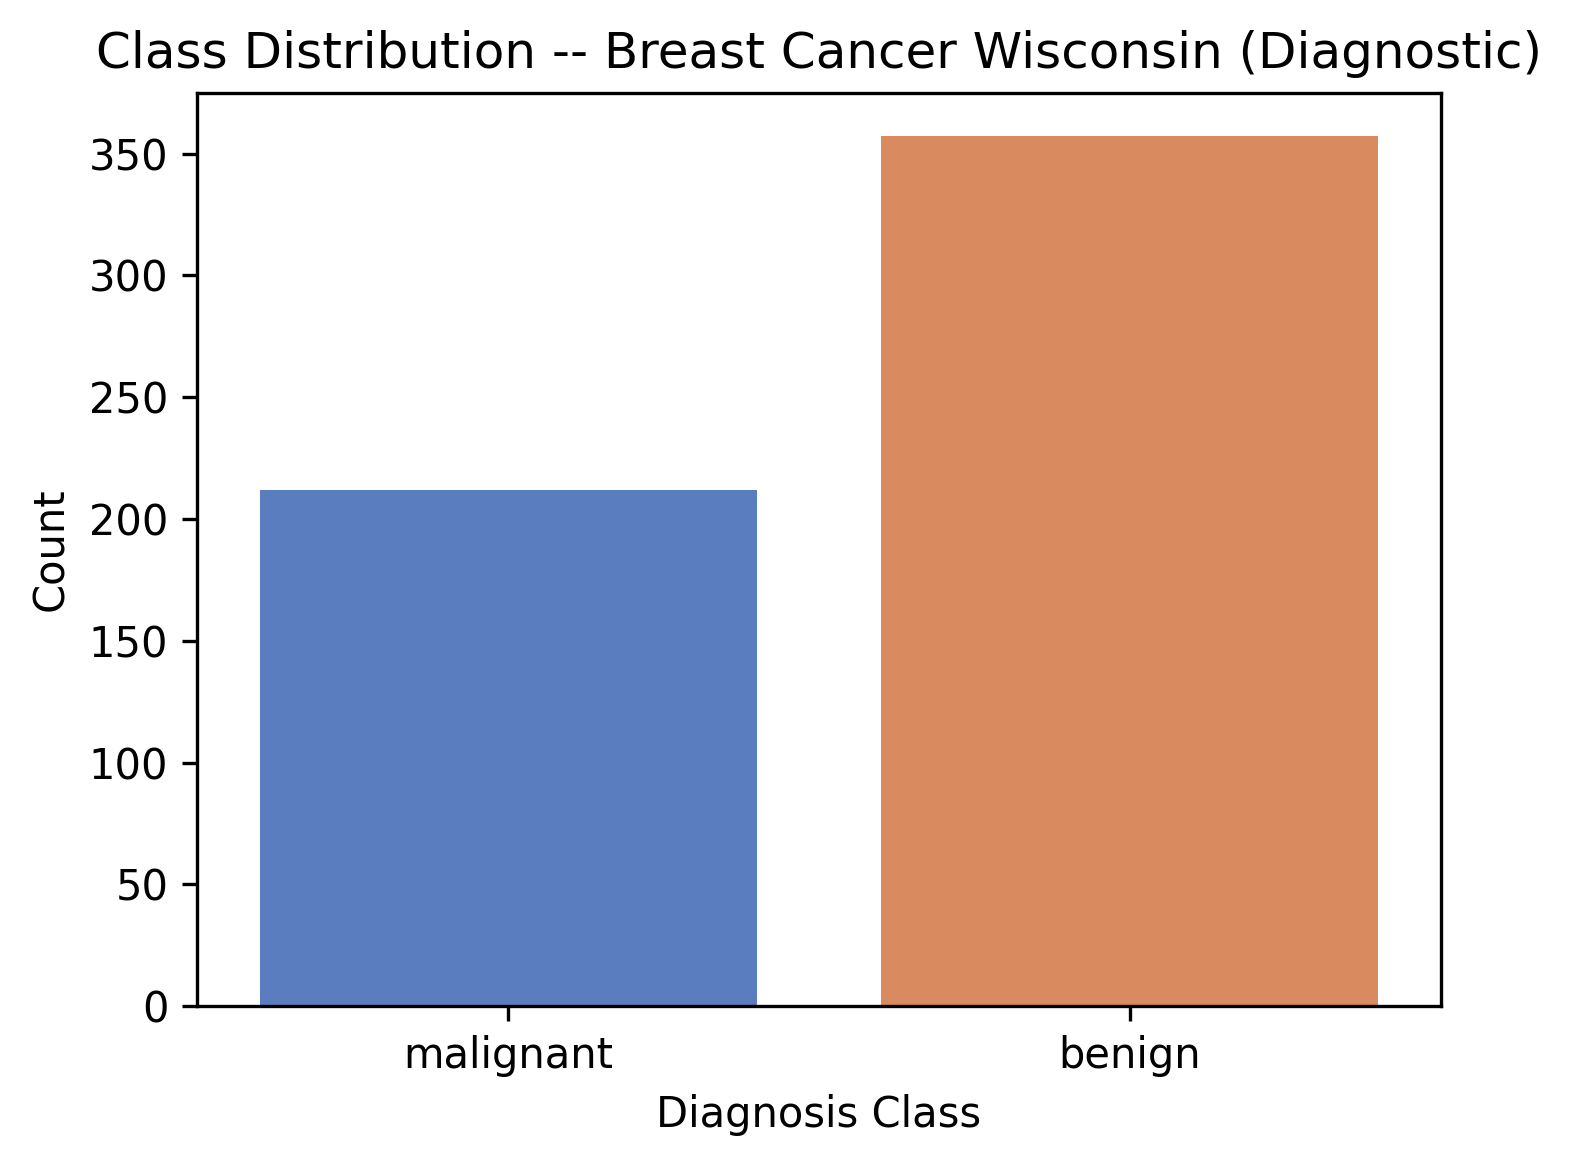

In [3]:
plt.figure(figsize=(5, 4))
sns.countplot(x=y_target.map({0: "malignant", 1: "benign"}), palette="muted")
plt.title("Class Distribution -- Breast Cancer Wisconsin (Diagnostic)")
plt.xlabel("Diagnosis Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("exp6_figures/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


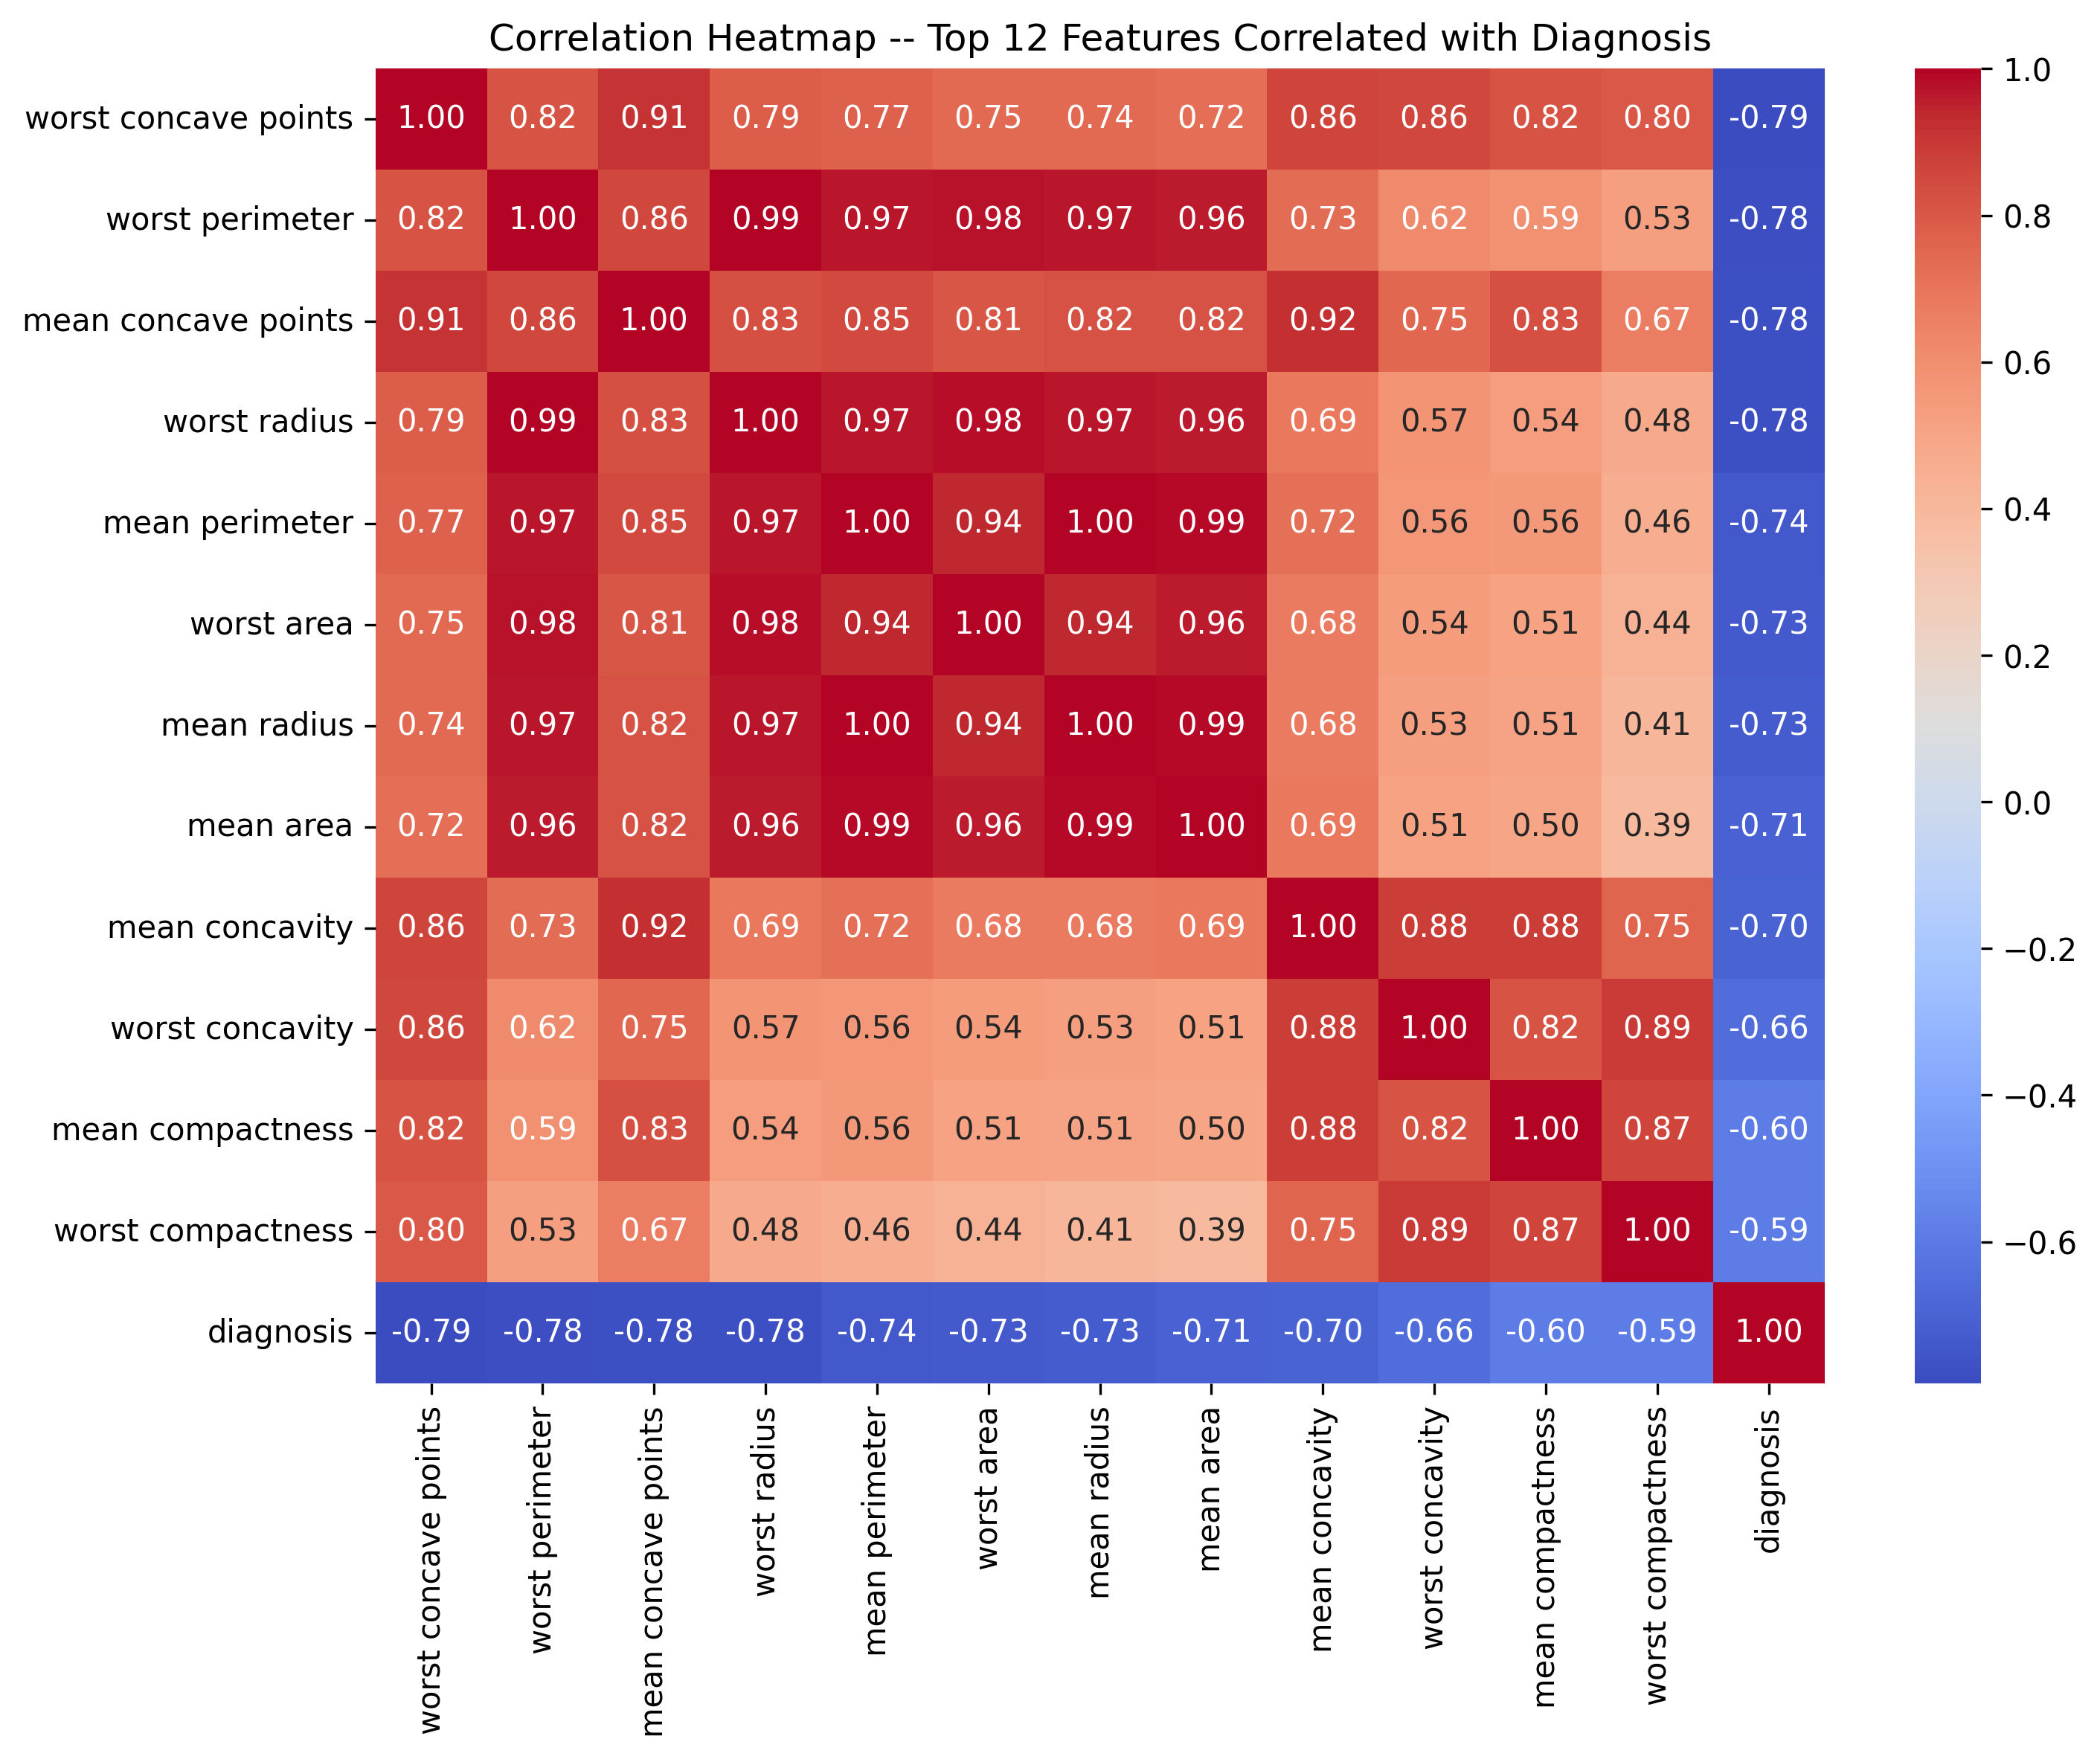

In [4]:
top_corr_features = X_features.corrwith(y_target).abs().sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X_features[top_corr_features], y_target], axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap -- Top 12 Features Correlated with Diagnosis")
plt.tight_layout()
plt.savefig("exp6_figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Stratified Train-Test Dataset Splitting (80:20)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.20, stratify=y_target, random_state=SEED_VAL
)
print("Training set shape:", X_train.shape, " Testing set shape:", X_test.shape)


Training set shape: (455, 30)  Testing set shape: (114, 30)


In [6]:
def evaluate_ensemble_model(model_obj, train_x, train_y, test_x, test_y):
    start_time = time.time()
    model_obj.fit(train_x, train_y)
    t_train = time.time() - start_time
    
    start_pred = time.time()
    y_pred = model_obj.predict(test_x)
    t_pred = time.time() - start_pred
    
    if hasattr(model_obj, "predict_proba"):
        y_prob = model_obj.predict_proba(test_x)[:, 1]
    elif hasattr(model_obj, "decision_function"):
        y_prob = model_obj.decision_function(test_x)
    else:
        y_prob = y_pred
        
    perf_metrics = {
        "Accuracy": accuracy_score(test_y, y_pred),
        "Precision": precision_score(test_y, y_pred),
        "Recall": recall_score(test_y, y_pred),
        "F1": f1_score(test_y, y_pred),
        "ROC_AUC": roc_auc_score(test_y, y_prob),
        "TrainTime": t_train,
        "PredictTime": t_pred
    }
    return perf_metrics, y_pred, y_prob

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED_VAL)


## 4. Bagging Classifier: Hyperparameter Search & 5-Fold CV


In [7]:
bagging_params = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

bagging_base = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED_VAL), random_state=SEED_VAL)
bag_grid = GridSearchCV(bagging_base, param_grid=bagging_params, cv=cv_stratified, scoring="accuracy", n_jobs=-1)
bag_grid.fit(X_train, y_train)

print("Best Bagging Params:", bag_grid.best_params_)
print("Best Bagging CV Accuracy:", round(bag_grid.best_score_, 4))


Best Bagging Params: {'max_features': 0.5, 'max_samples': 0.5, 'n_estimators': 50}
Best Bagging CV Accuracy: 0.9604


In [8]:
best_bagging_model = bag_grid.best_estimator_
bag_metrics, bag_pred, bag_prob = evaluate_ensemble_model(best_bagging_model, X_train, y_train, X_test, y_test)
bag_metrics


{'Accuracy': 0.956140350877193, 'Precision': 0.958904109589041, 'Recall': 0.9722222222222222, 'F1': 0.9655172413793104, 'ROC_AUC': 0.9930555555555556, 'TrainTime': 0.09558796882629395, 'PredictTime': 0.003848552703857422}

## 5. Boosting Classifiers (AdaBoost & Gradient Boosting)


In [9]:
adaboost_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2, 1.0]
}

ada_grid = GridSearchCV(AdaBoostClassifier(random_state=SEED_VAL), param_grid=adaboost_params, cv=cv_stratified, scoring="accuracy", n_jobs=-1)
ada_grid.fit(X_train, y_train)

print("Best AdaBoost Params:", ada_grid.best_params_)
print("Best AdaBoost CV Accuracy:", round(ada_grid.best_score_, 4))


Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 100}
Best AdaBoost CV Accuracy: 0.9802


In [10]:
gb_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=SEED_VAL), param_grid=gb_params, cv=cv_stratified, scoring="accuracy", n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("Best GradientBoosting Params:", gb_grid.best_params_)
print("Best GradientBoosting CV Accuracy:", round(gb_grid.best_score_, 4))


Best GradientBoosting Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150}
Best GradientBoosting CV Accuracy: 0.9692


## 6. Stacked Ensemble (Heterogeneous Base Learners + Logistic Regression Meta-Learner)


In [11]:
base_estimators = [
    ("dt", DecisionTreeClassifier(max_depth=5, random_state=SEED_VAL)),
    ("nb", GaussianNB()),
    ("svm", make_pipeline(StandardScaler(), SVC(probability=True, random_state=SEED_VAL)))
]

meta_learner = LogisticRegression(random_state=SEED_VAL)

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5
)

stack_cv_score = cross_val_score(stacking_clf, X_features, y_target, cv=cv_stratified, scoring="accuracy").mean()
print("Stacked Ensemble 5-Fold CV Accuracy:", round(stack_cv_score, 4))


Stacked Ensemble 5-Fold CV Accuracy: 0.9543


## 7. 5-Fold Cross-Validation Performance Comparison Across Ensembles


In [12]:
bag_cv_scores = cross_val_score(best_bagging_model, X_features, y_target, cv=cv_stratified, scoring="accuracy")
ada_cv_scores = cross_val_score(best_ada_model, X_features, y_target, cv=cv_stratified, scoring="accuracy")
gb_cv_scores = cross_val_score(best_gb_model, X_features, y_target, cv=cv_stratified, scoring="accuracy")
stack_cv_scores = cross_val_score(stacking_clf, X_features, y_target, cv=cv_stratified, scoring="accuracy")

cv_table = pd.DataFrame({
    "Fold 1": [bag_cv_scores[0], ada_cv_scores[0], gb_cv_scores[0], stack_cv_scores[0]],
    "Fold 2": [bag_cv_scores[1], ada_cv_scores[1], gb_cv_scores[1], stack_cv_scores[1]],
    "Fold 3": [bag_cv_scores[2], ada_cv_scores[2], gb_cv_scores[2], stack_cv_scores[2]],
    "Fold 4": [bag_cv_scores[3], ada_cv_scores[3], gb_cv_scores[3], stack_cv_scores[3]],
    "Fold 5": [bag_cv_scores[4], ada_cv_scores[4], gb_cv_scores[4], stack_cv_scores[4]],
    "Average": [bag_cv_scores.mean(), ada_cv_scores.mean(), gb_cv_scores.mean(), stack_cv_scores.mean()]
}, index=["Bagging", "AdaBoost", "Gradient Boosting", "Stacked Ensemble"])

cv_table.round(4)


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
Bagging,0.9561,0.9298,0.9386,0.9561,0.9735,0.9508
AdaBoost,0.9912,0.9386,0.9561,0.9737,0.9735,0.9666
Gradient Boosting,0.9737,0.9035,0.9561,0.9737,0.9823,0.9579
Stacked Ensemble,0.9737,0.9211,0.9649,0.9474,0.9646,0.9543


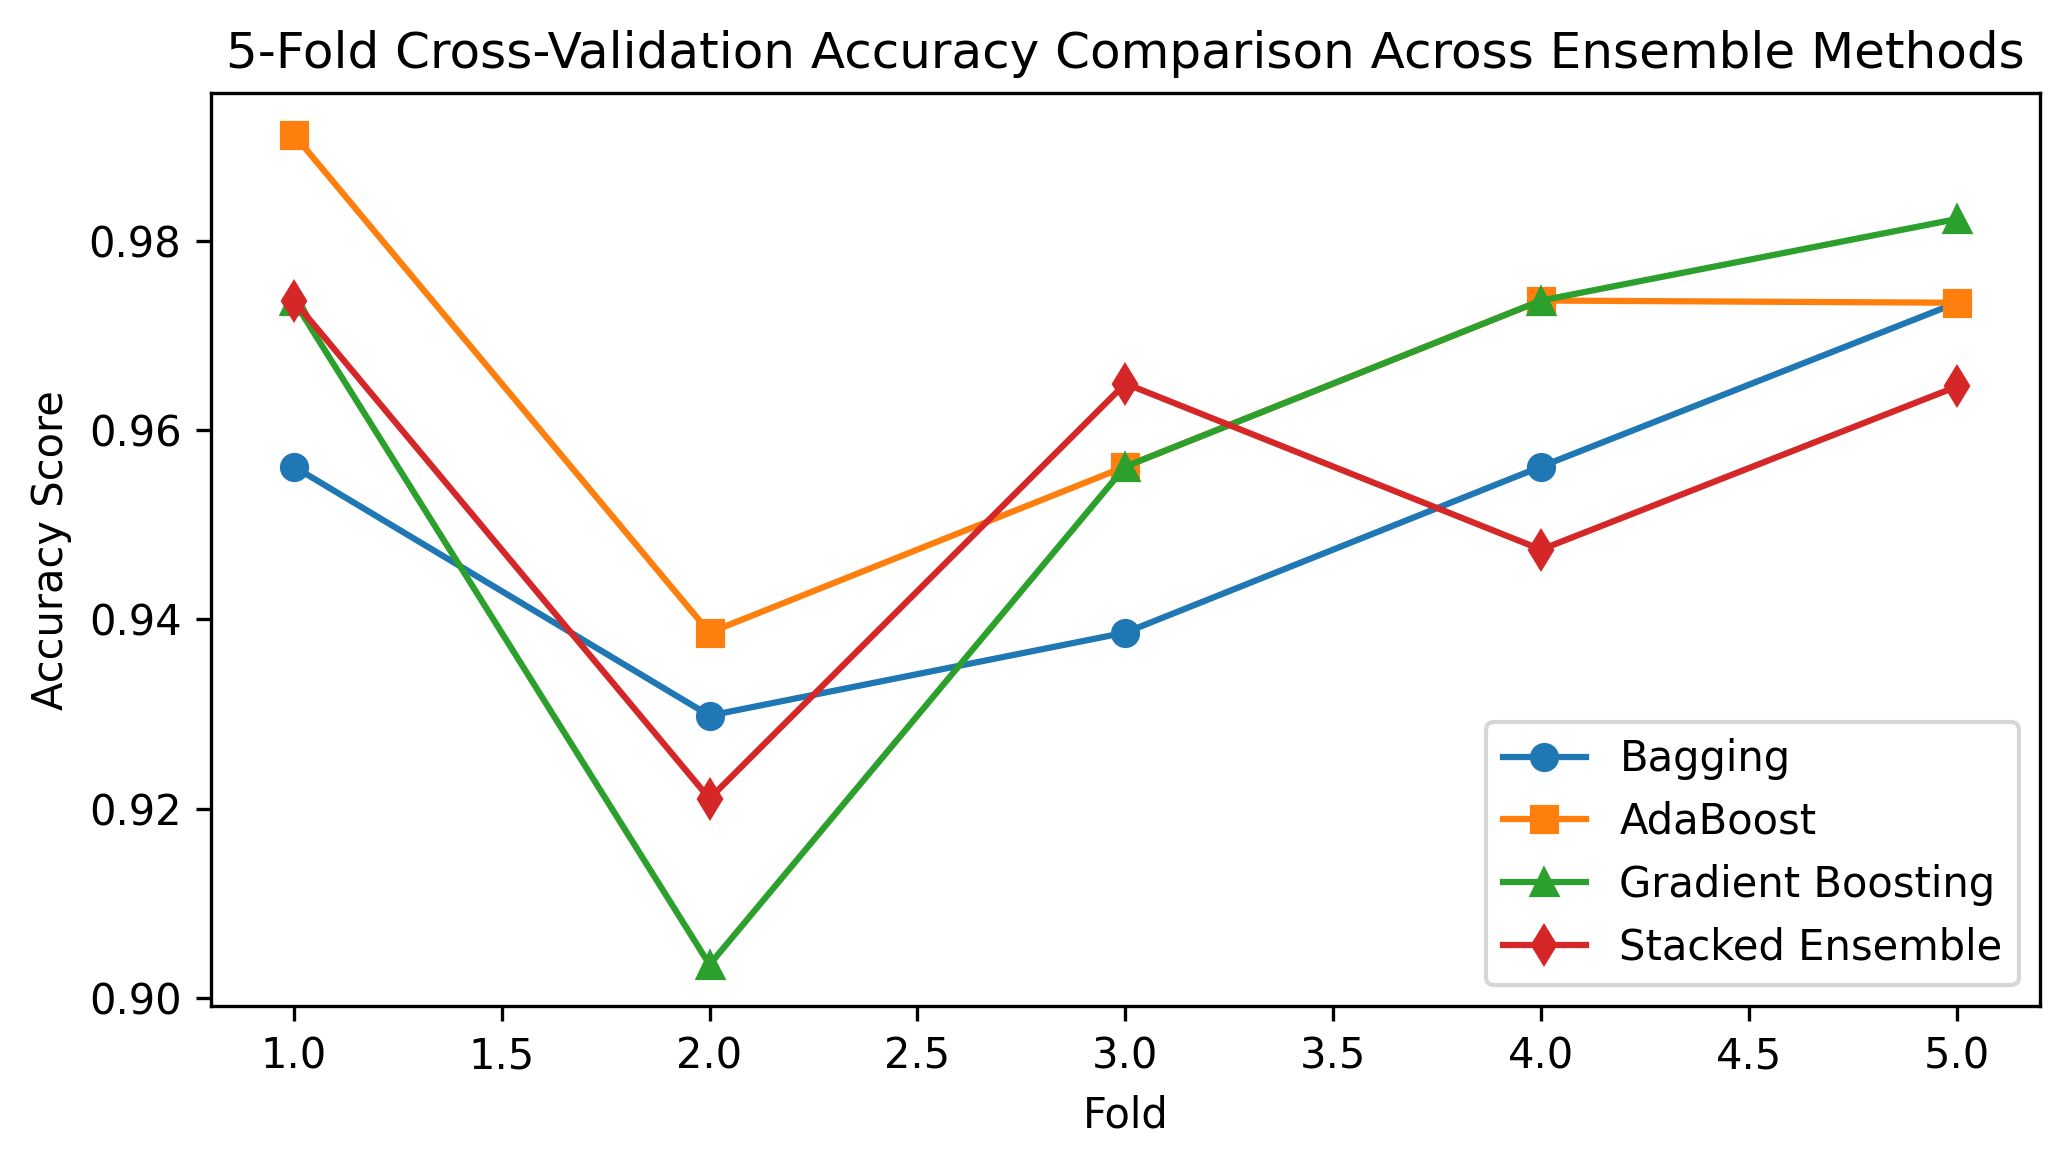

In [13]:
plt.figure(figsize=(7, 4))
folds = list(range(1, 6))
plt.plot(folds, bag_cv_scores, "o-", label="Bagging")
plt.plot(folds, ada_cv_scores, "s-", label="AdaBoost")
plt.plot(folds, gb_cv_scores, "^-", label="Gradient Boosting")
plt.plot(folds, stack_cv_scores, "d-", label="Stacked Ensemble")
plt.xlabel("Fold")
plt.ylabel("Accuracy Score")
plt.title("5-Fold Cross-Validation Accuracy Comparison Across Ensemble Methods")
plt.legend()
plt.tight_layout()
plt.savefig("exp6_figures/cv_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Confusion Matrices and ROC-AUC Curves


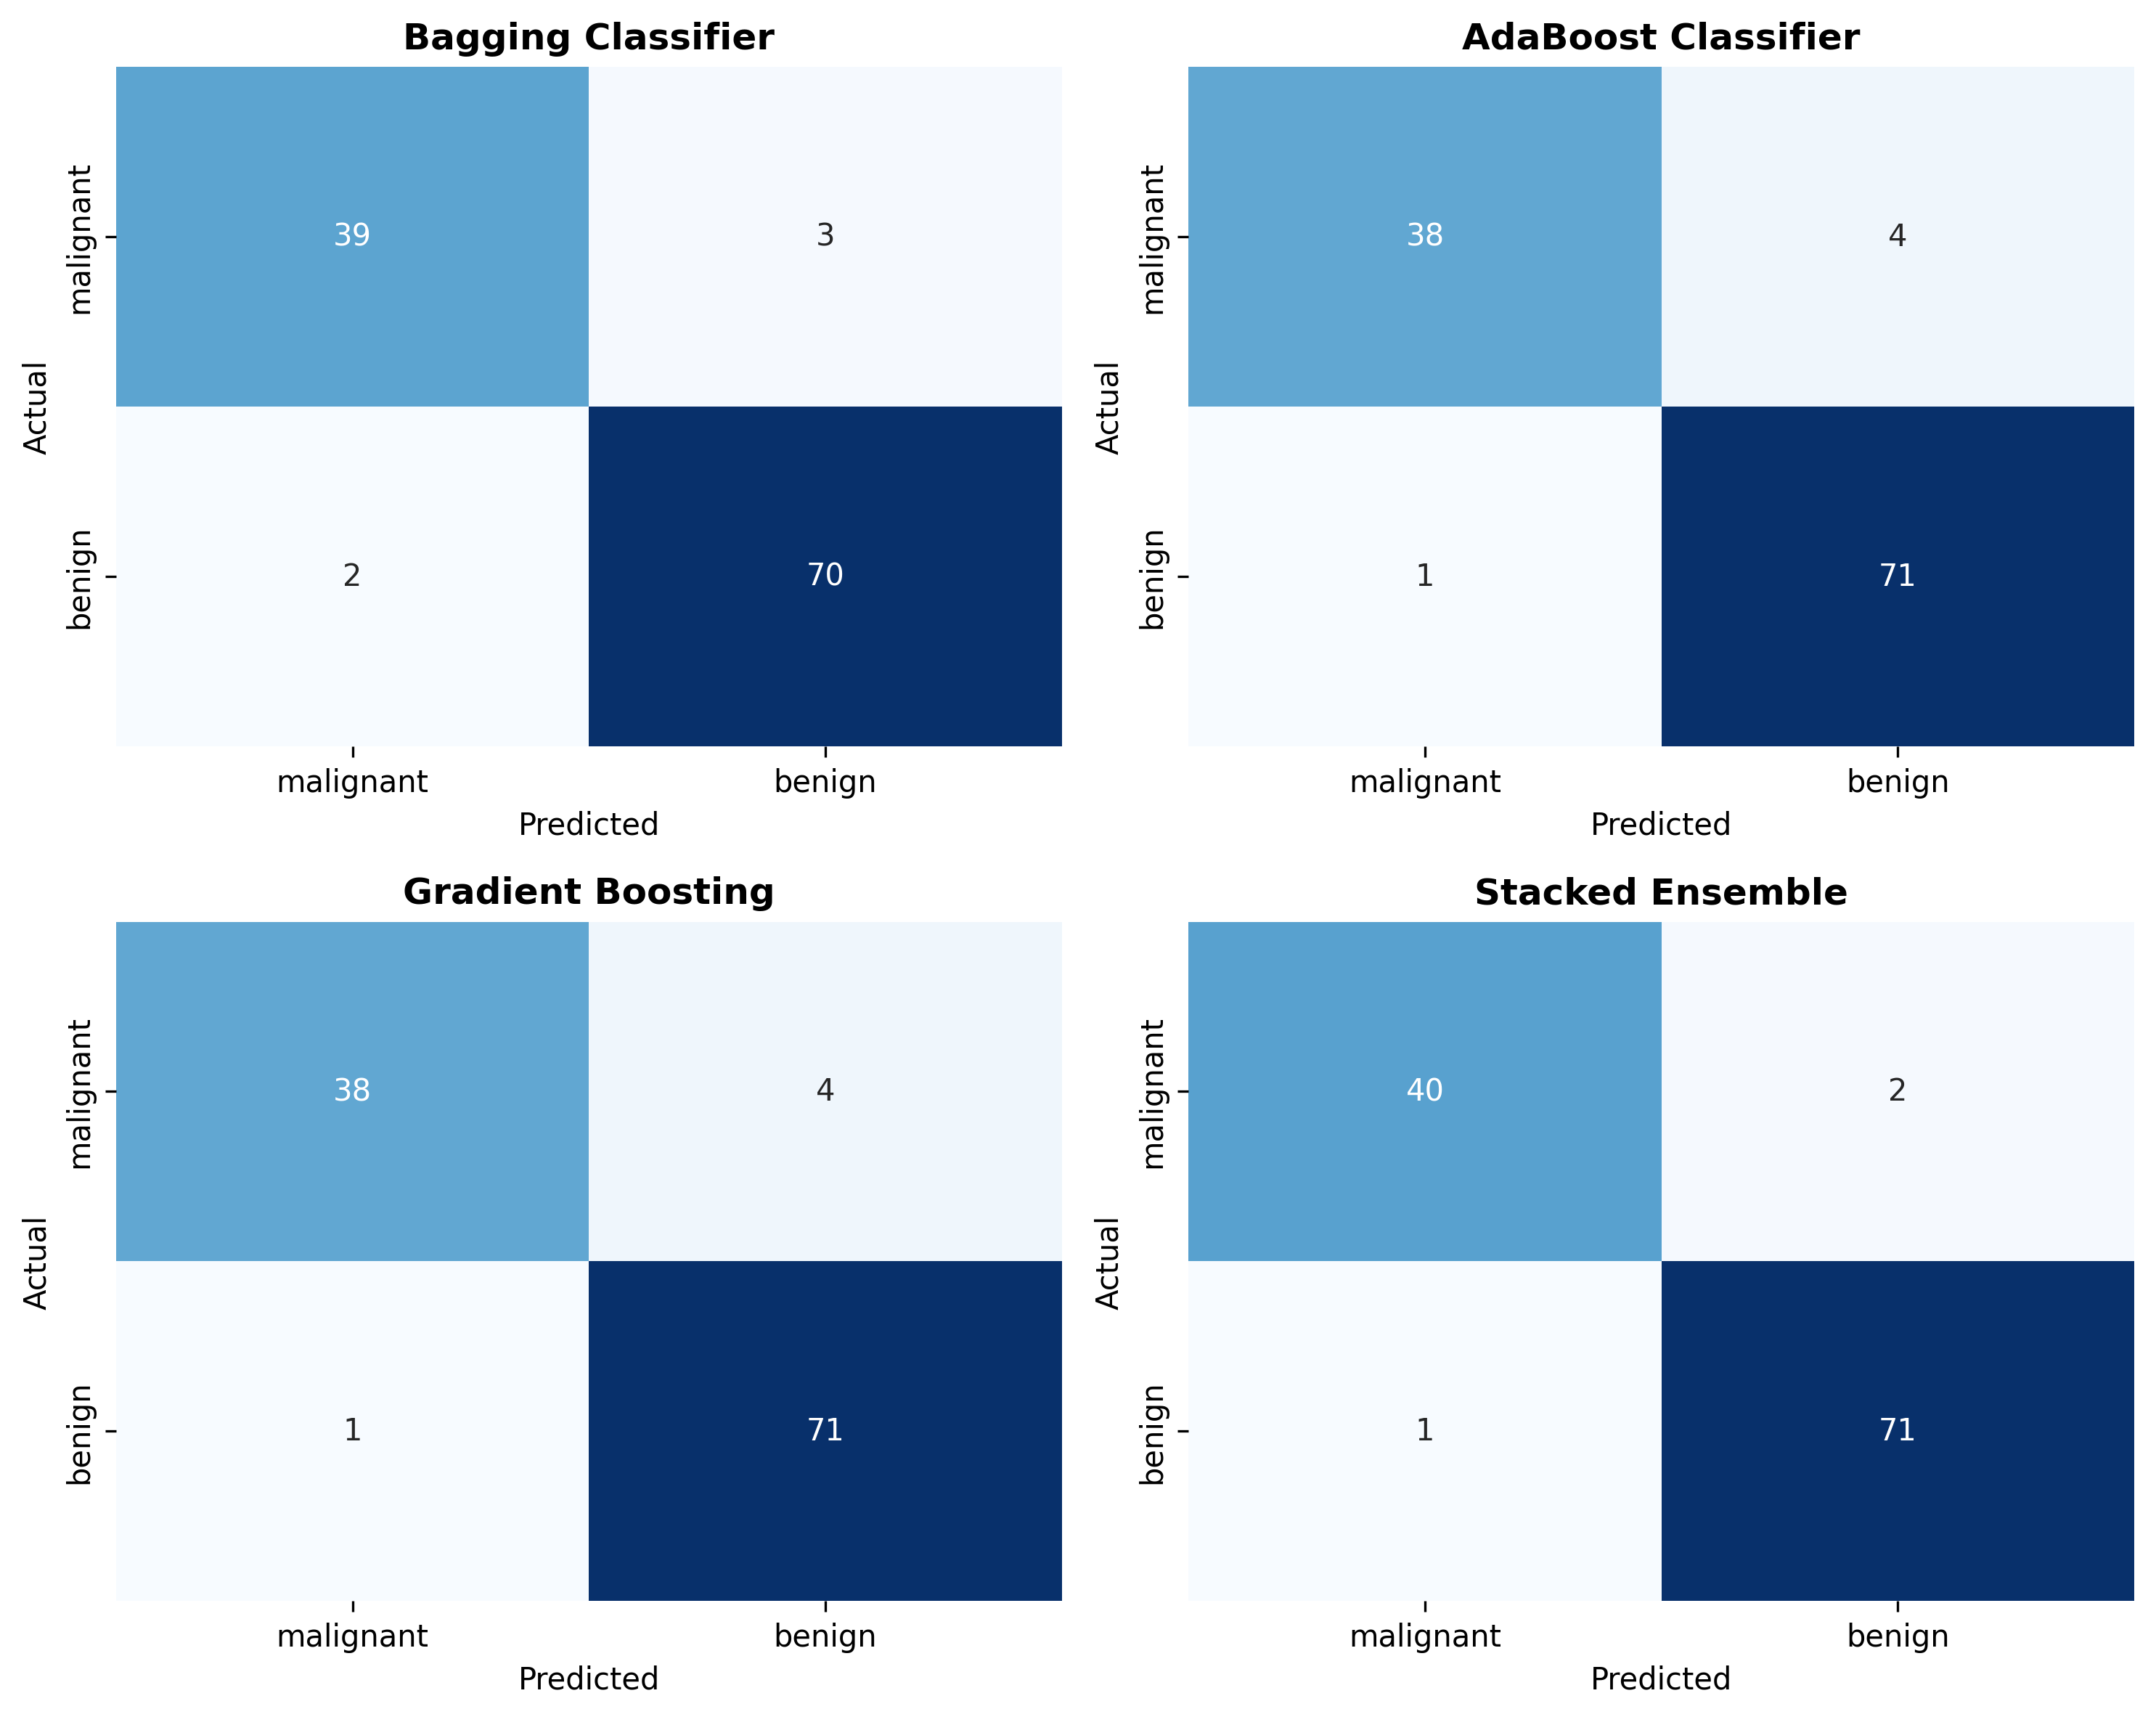

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
models_info = [
    ("Bagging Classifier", bag_pred, axes[0, 0]),
    ("AdaBoost Classifier", ada_pred, axes[0, 1]),
    ("Gradient Boosting", gb_pred, axes[1, 0]),
    ("Stacked Ensemble", stack_pred, axes[1, 1])
]

for title, pred_vals, ax in models_info:
    cm = confusion_matrix(y_test, pred_vals)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["malignant", "benign"], yticklabels=["malignant", "benign"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("exp6_figures/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


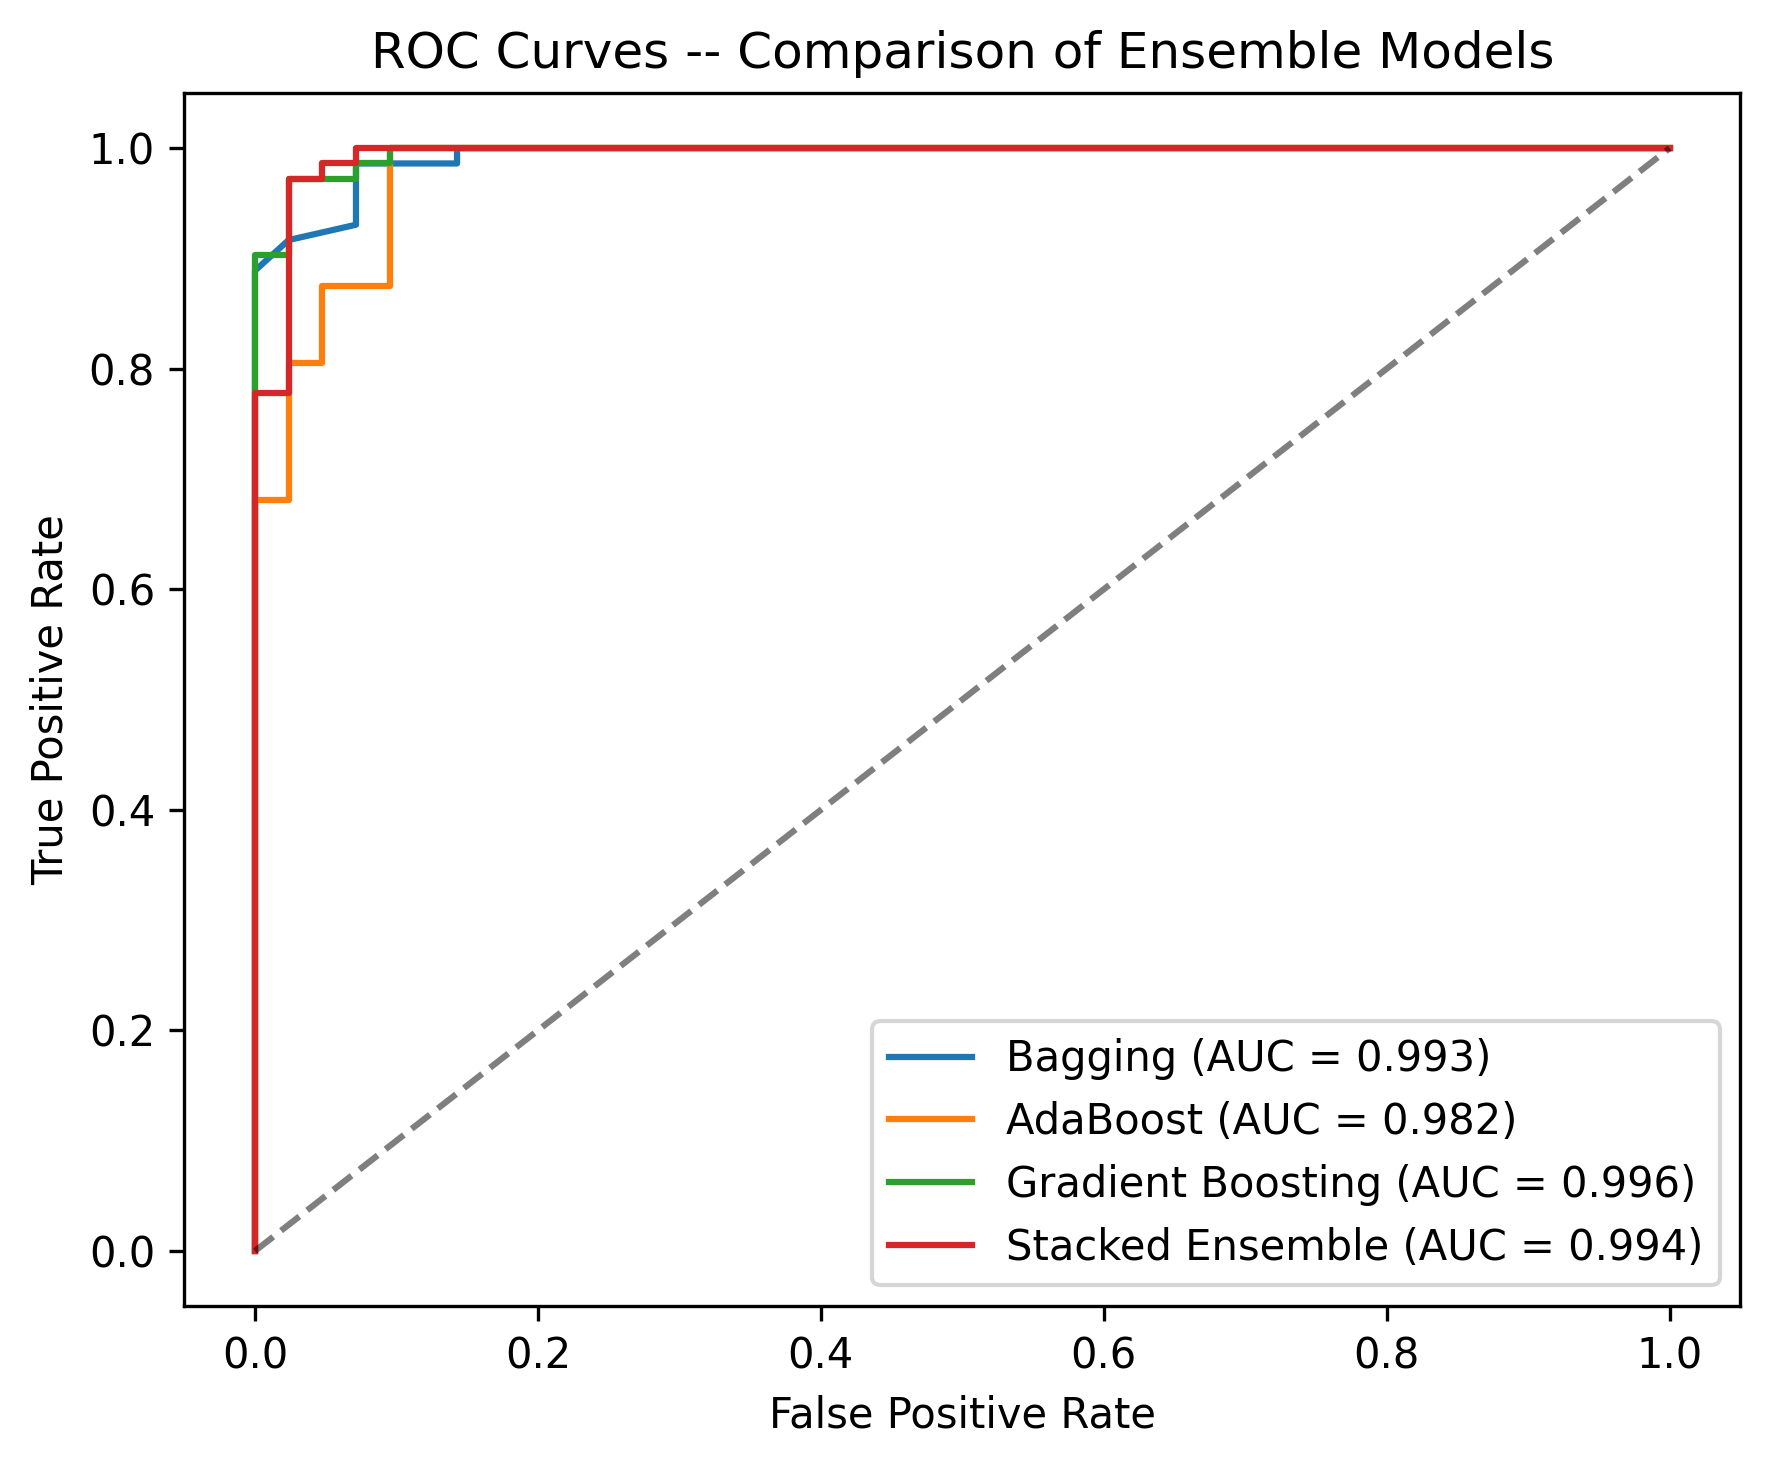

In [15]:
plt.figure(figsize=(6, 5))

for name, proba_vals in [("Bagging", bag_prob), ("AdaBoost", ada_prob), ("Gradient Boosting", gb_prob), ("Stacked Ensemble", stack_prob)]:
    fpr, tpr, _ = roc_curve(y_test, proba_vals)
    auc_val = roc_auc_score(y_test, proba_vals)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves -- Comparison of Ensemble Models")
plt.legend()
plt.tight_layout()
plt.savefig("exp6_figures/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Feature Importance (Gradient Boosting)


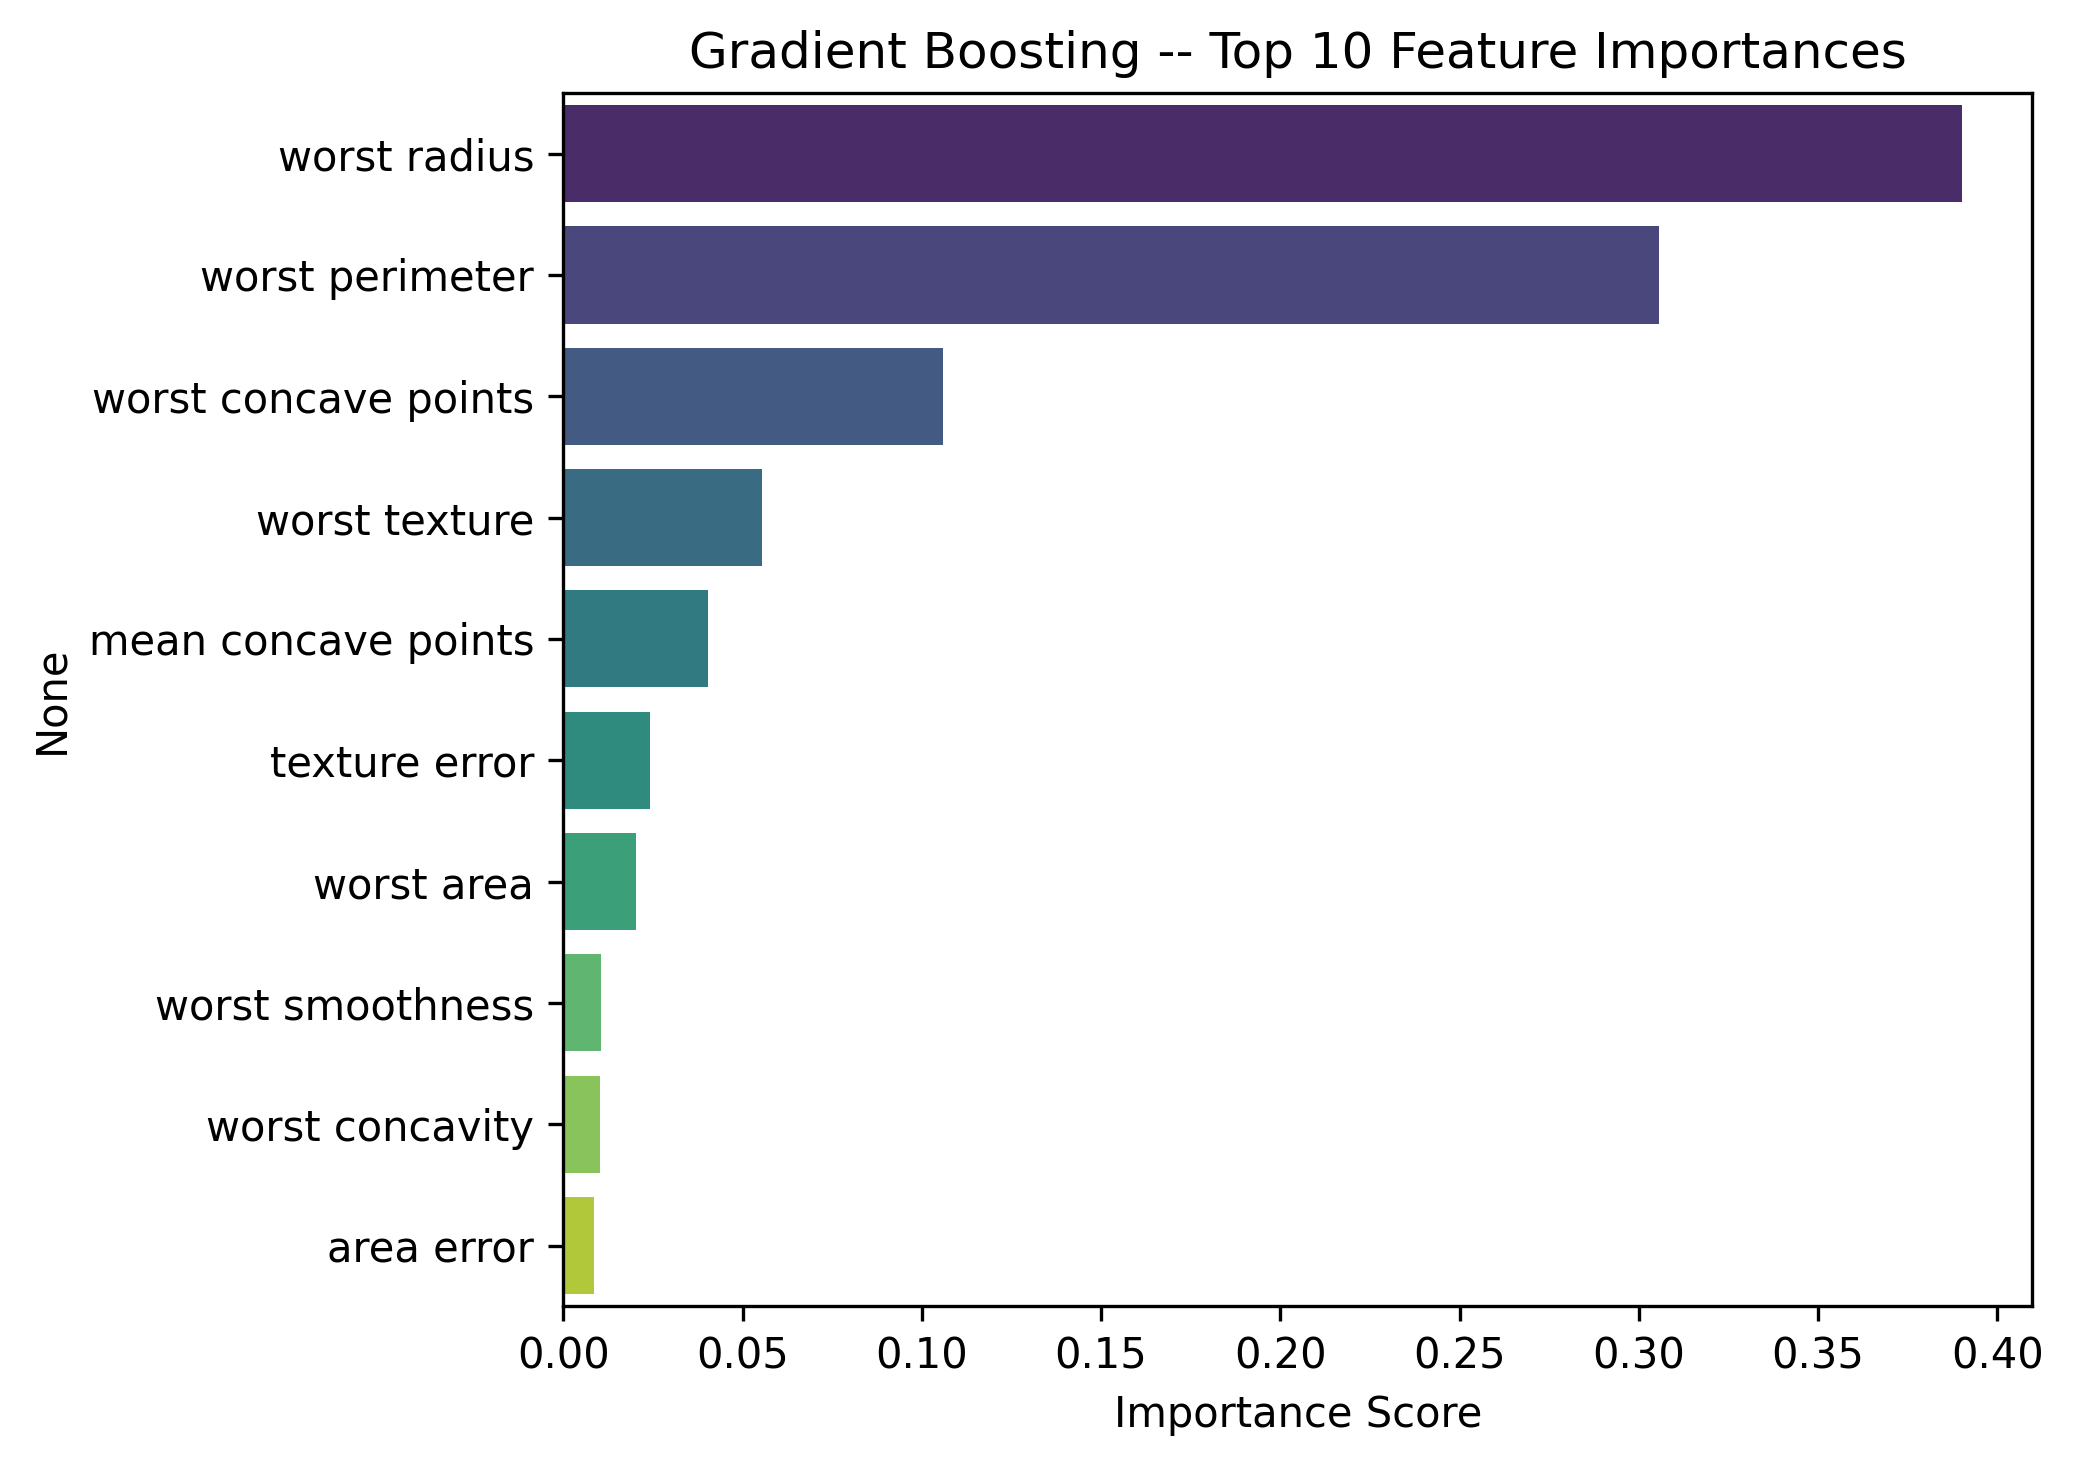

In [16]:
gb_importances = pd.Series(best_gb_model.feature_importances_, index=X_features.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 5))
sns.barplot(x=gb_importances.values, y=gb_importances.index, palette="viridis")
plt.title("Gradient Boosting -- Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("exp6_figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Comprehensive Performance Comparison of Ensemble Models


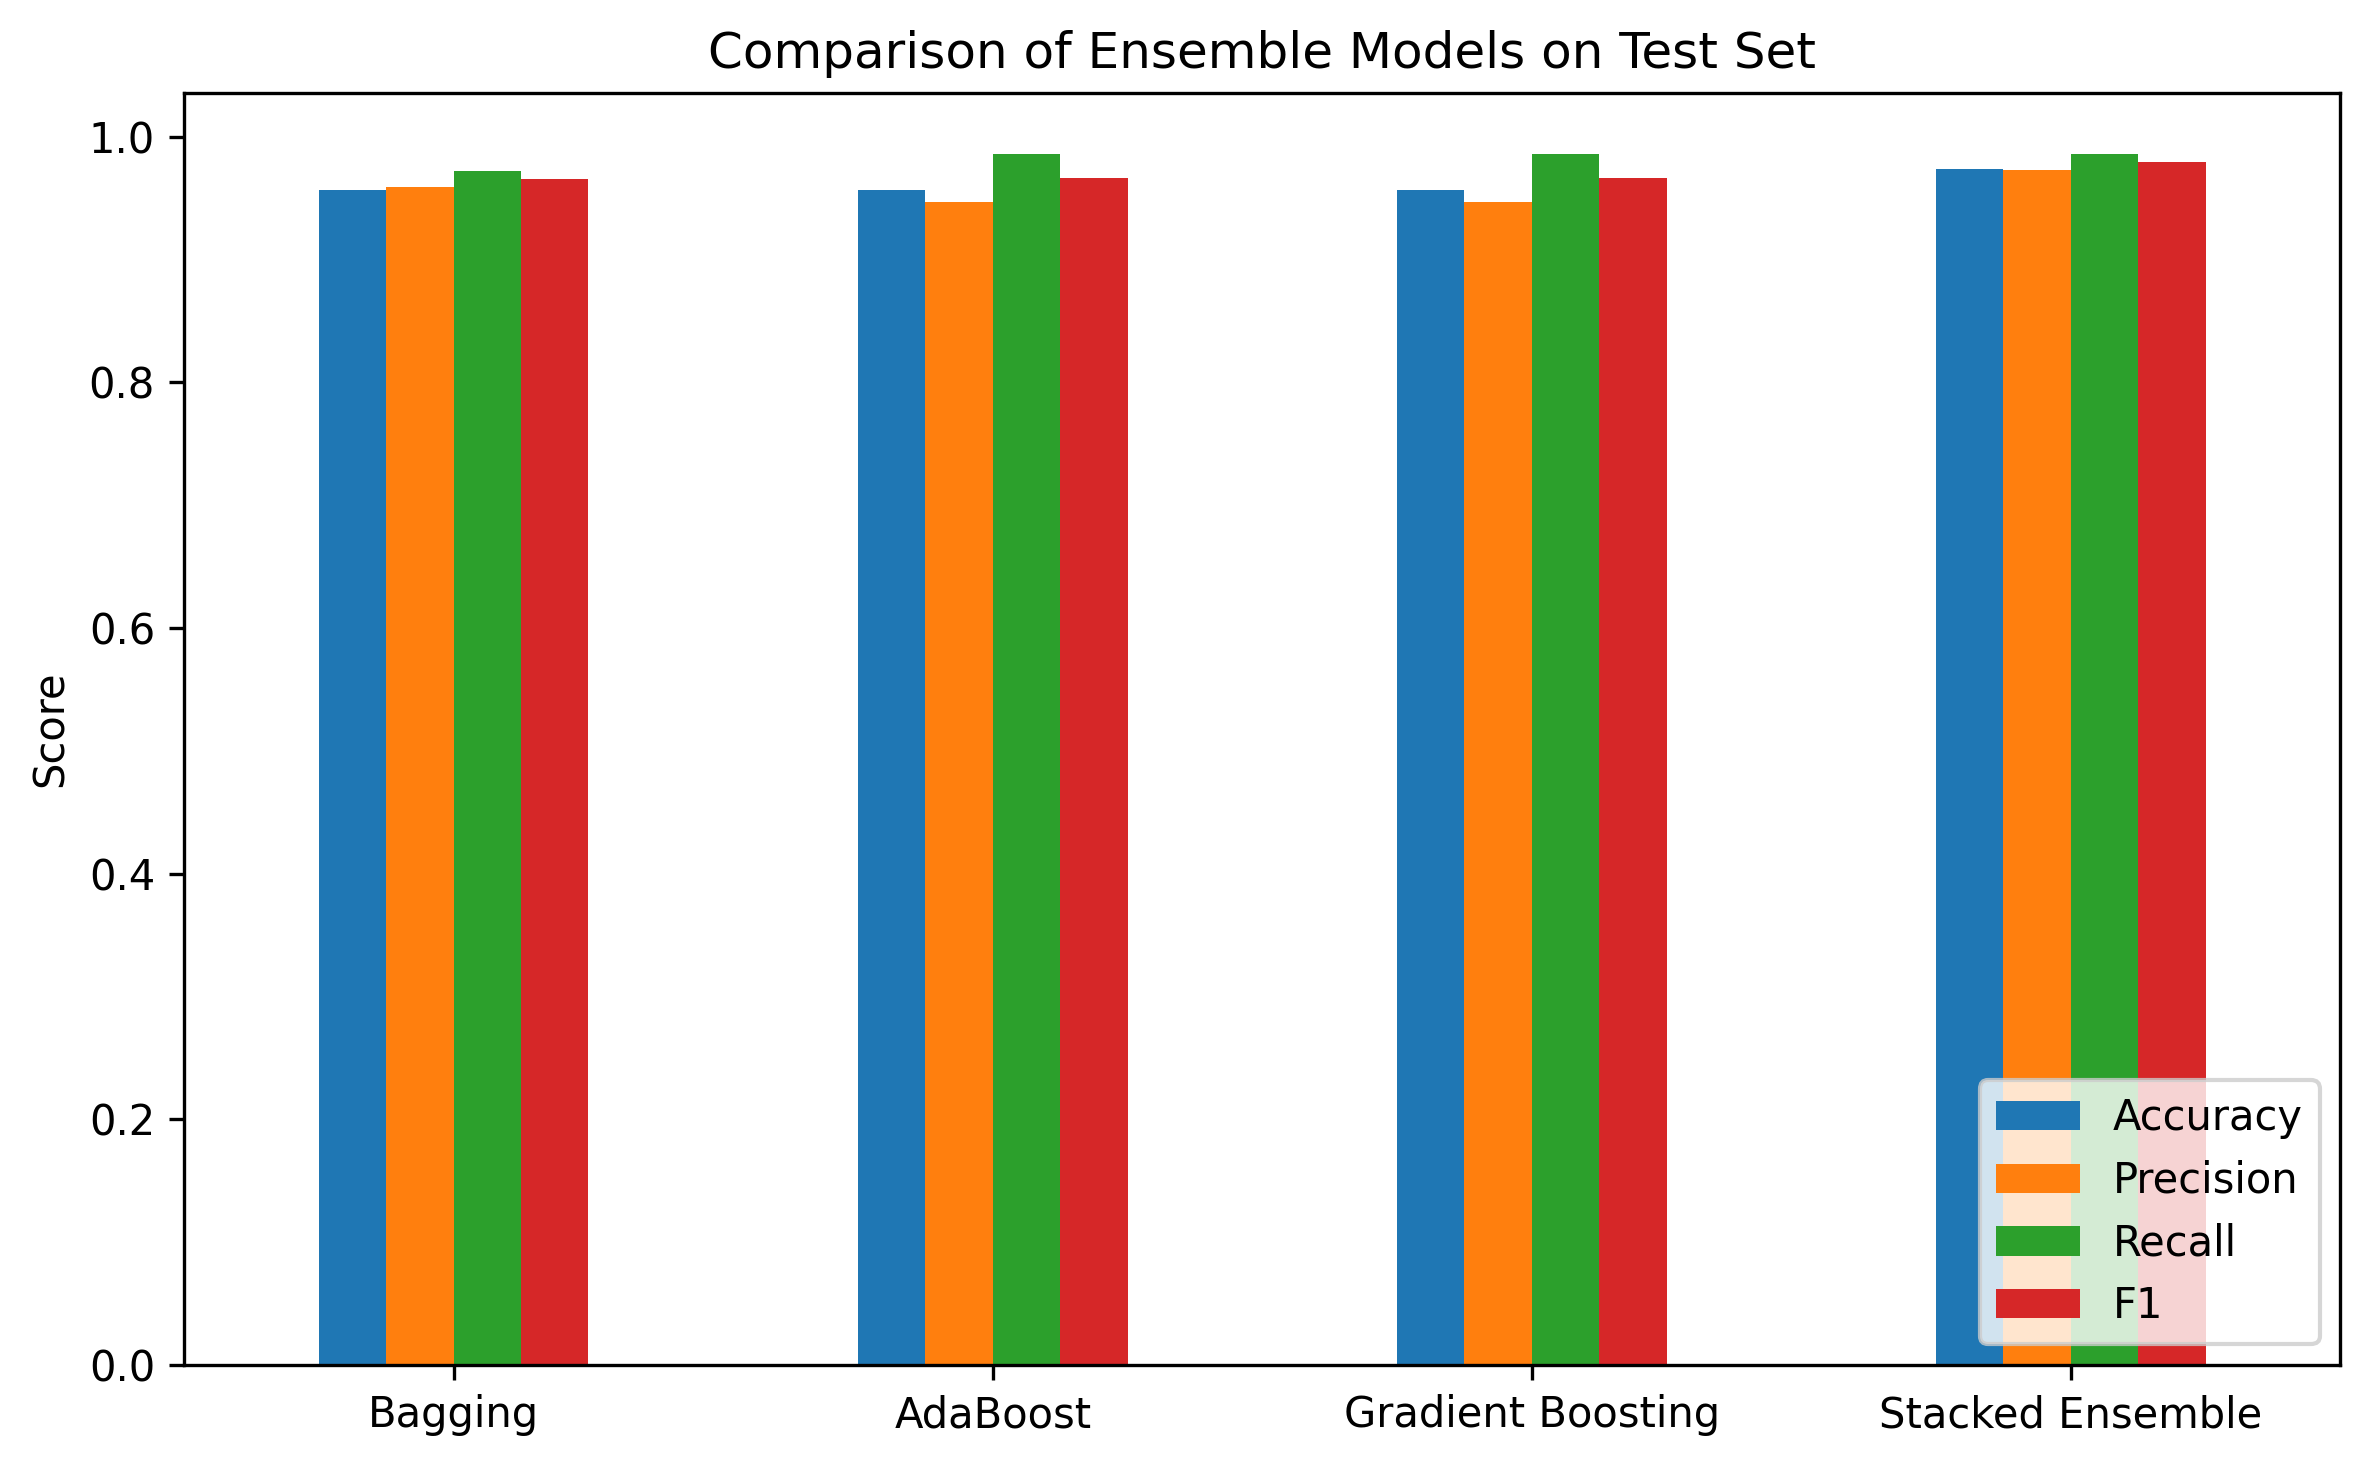

,Accuracy,Precision,Recall,F1,ROC_AUC
Bagging,0.9561,0.9589,0.9722,0.9655,0.9931
AdaBoost,0.9561,0.9467,0.9861,0.9660,0.9818
Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9960
Stacked Ensemble,0.9737,0.9726,0.9861,0.9793,0.9937


In [17]:
ensemble_metrics_df = pd.DataFrame({
    "Bagging": bag_metrics,
    "AdaBoost": ada_metrics,
    "Gradient Boosting": gb_metrics,
    "Stacked Ensemble": stack_metrics
}).T[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]

plt.figure(figsize=(8, 5))
ensemble_metrics_df[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(8, 5))
plt.title("Comparison of Ensemble Models on Test Set")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("exp6_figures/ensemble_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

ensemble_metrics_df.round(4)


## Summary

See the accompanying report (`Experiment6.pdf` / `Experiment6.tex`) for full theoretical explanations, bias-variance trade-off analysis, hyperparameter tuning evaluation tables, and observation responses.
